In [32]:
import pandas as pd   # Pour manipuler les données sous forme de tableaux (DataFrame)
import seaborn as sns  #Pour faire des visualisations statistiques
import matplotlib.pyplot as plt  # Pour contrôler l'affichage des graphiques
sns.set(style="whitegrid") # Définir un style graphique par défaut pour Seaborn (fond clair, grilles, etc.)

In [33]:
df = pd.read_csv("netflix_titles.csv") # Charger le fichier CSV contenant les données Netflix

In [34]:
# Afficher les 5 premières lignes pour voir à quoi ressemble le dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [35]:
# Afficher des informations générales sur le DataFrame :
# - nombre de lignes et colonnes
# - type de chaque colonne (object, int, float, datetime...)
# - nombre de valeurs non nulles
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [36]:
# Voir combien de valeurs manquantes il y a dans chaque colonne
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [37]:
#country
#La colonne country est essentielle pour l’analyse géographique.
#On ne veut pas supprimer les lignes, mais on ne peut pas remplacer par le mode, car ça fausserait les stats.
#On remplace les NaN par "Unknown" (pays non spécifié). 
df["country"] = df["country"].fillna("Unknown")

In [38]:
#rating
#La variable rating présente très peu de valeurs manquantes.
#Elles ont été remplacées par la modalité la plus fréquente afin de conserver la cohérence de cette variable catégorielle
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

In [39]:
#duration
#On a 3 valeurs manquantes dans duration.
#Cette colonne est essentielle pour comparer la durée des films vs séries (boxplot).
# Supprimer les lignes où la durée est manquante
df = df.dropna(subset=["duration"])

In [40]:

#on veut une colonne propre pour créer l’année d’ajout. 
#Supprimer 10 lignes sur >5 000 n’a presque aucun impact.#date_added
df = df.dropna(subset=["date_added"])

In [41]:
# Conversion sécurisée des dates (pandas reconnaît parfaitement le format Month Day, Year)
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [42]:
df["date_added"].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

In [43]:
#La colonne date_added contient une date complète, qui n’est pas pratique à analyser telle quelle.
#Nous avons donc extrait uniquement l’année d’ajout dans une nouvelle colonne year_added, 
#ce qui permet de visualiser facilement la progression du nombre de contenus ajoutés par Netflix d’année en année.
df["year_added"] = df["date_added"].dt.year

In [44]:
df[["date_added", "year_added"]].head()

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [45]:
cols_to_drop = ["show_id", "director", "cast", "description", "date_added"]
df = df.drop(columns=cols_to_drop)
#show_id : identifiant interne, n’apporte aucune information utile pour l’analyse.

#director : très nombreuses valeurs manquantes et non utilisé dans les visualisations.

#cast : texte long, difficile à exploiter et inutile pour les graphiques demandés.

#description : colonne textuelle non utilisée dans une analyse statistique.

#date_added : remplacée par year_added qui suffit pour l’analyse temporelle.
#« Nous avons conservé la colonne rating car elle permet d’analyser la classification d’âge des contenus Netflix.
#Cette variable n'est pas utilisée dans les visualisations obligatoires,
#mais elle est pertinente pour une analyse additionnelle portant sur le public ciblé par la plateforme. »


#Nous avons conservé la colonne year_added pour analyser l’évolution annuelle du catalogue Netflix. 
#Cette variable permet d’étudier la dynamique d’ajout de contenus sur la plateforme, 
#ce qui constitue une analyse additionnelle pertinente

In [46]:
df.isna().sum()

type             0
title            0
country          0
release_year     0
rating           0
duration         0
listed_in        0
year_added      88
dtype: int64

In [47]:
df = df.dropna(subset=["year_added"])


In [48]:
df.isna().sum()

type            0
title           0
country         0
release_year    0
rating          0
duration        0
listed_in       0
year_added      0
dtype: int64

In [49]:
df.head()

,type,title,country,release_year,rating,duration,listed_in,year_added
0,Movie,Dick Johnson Is Dead,United States,2020,PG-13,90 min,Documentaries,2021.0
1,TV Show,Blood & Water,South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021.0
2,TV Show,Ganglands,Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021.0
3,TV Show,Jailbirds New Orleans,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021.0
4,TV Show,Kota Factory,India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021.0


In [50]:
#countplot() – Films vs Séries
#barplot() – Top 10 Pays producteurs
#histplot() – Distribution des années de sortie
#heatmap() – Corrélation entre variables quantitatives
#boxplot() – Durée moyenne selon le type (Movie / TV Show)
#Analyse Additionnelle 1 : Répartition des contenus par Rating (classification d’âge)
#Analyse Additionnelle 2 : Évolution des contenus ajoutés par Année (year_added)

In [51]:
#Netflix propose nettement plus de films que de séries.
#Les films représentent la majorité du catalogue, 
#ce qui montre une orientation plus forte vers le contenu cinématographique

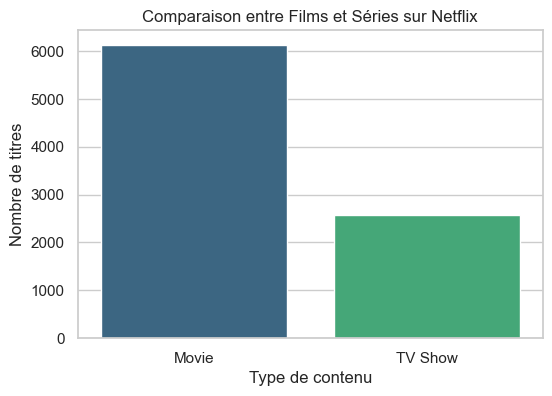

In [52]:
#1 countplot — Films vs Séries / But : comparer la quantité de films et de séries.
fig_films_series = plt.figure(figsize=(6,4))
sns.countplot(data=df, x="type", palette="viridis")
plt.title("Comparaison entre Films et Séries sur Netflix")
plt.xlabel("Type de contenu")
plt.ylabel("Nombre de titres")
plt.show()

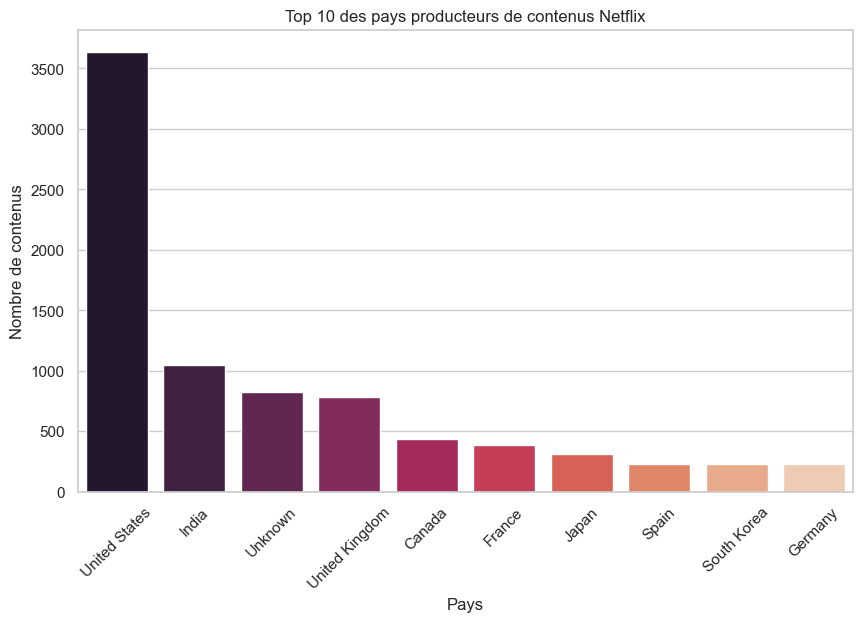

In [53]:
#2 barplot — Top 10 pays producteurs 
# Séparer les pays et compter les occurrences
top10 = df["country"].str.split(", ").explode().value_counts().head(10).reset_index()
top10.columns = ["country", "count"]
fig_top10 = plt.figure(figsize=(10,6))
sns.barplot(data=top10, x="country", y="count", palette="rocket")
plt.title("Top 10 des pays producteurs de contenus Netflix")
plt.xticks(rotation=45)
plt.xlabel("Pays")
plt.ylabel("Nombre de contenus")
plt.show()

In [54]:
#Les États-Unis dominent largement la production de contenus présents sur Netflix, suivis par l’Inde, 
#le Royaume-Uni et le Canada.
#Cela reflète le poids industriel du cinéma américain et l’importance des productions locales indiennes. »

C:\Users\micro\anacondaa\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


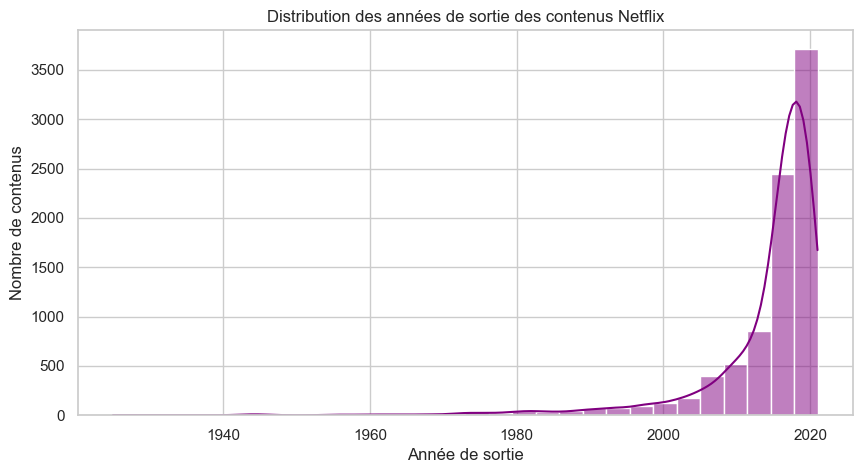

In [55]:
#histplot — Distribution des années de sortie (release_year)  / But : analyser l’ancienneté des contenus.
fig_hist_release_year = plt.figure(figsize=(10,5))
sns.histplot(data=df, x="release_year", bins=30, kde=True, color="purple")
plt.title("Distribution des années de sortie des contenus Netflix")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")
plt.show()

In [56]:
#« La majorité des contenus présents sur Netflix ont été produits entre 2000 et 2020.
#On observe une concentration importante dans les années récentes,
#ce qui montre que Netflix propose principalement des contenus modernes. »

In [57]:
#Boxplot — Durée des Films vs Séries

#Avant tout, on doit bien comprendre que :

#Films → durée en minutes

#Séries → durée en saisons

#On peut visualiser les deux, mais on les interprète séparément, car ce ne sont pas les mêmes unités.
#solution trouvée:Créer les colonnes duration_value et duration_unit

In [58]:
# Extraire la partie numérique (minutes ou nombre de saisons)
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(int)

# Définir l'unité : minutes pour films, seasons pour séries
df["duration_unit"] = df["duration"].apply(
    lambda x: "min" if "min" in x.lower() else "season"
)

In [59]:
df[["type", "duration", "duration_value", "duration_unit"]].head()

,type,duration,duration_value,duration_unit
0,Movie,90 min,90,min
1,TV Show,2 Seasons,2,season
2,TV Show,1 Season,1,season
3,TV Show,1 Season,1,season
4,TV Show,2 Seasons,2,season


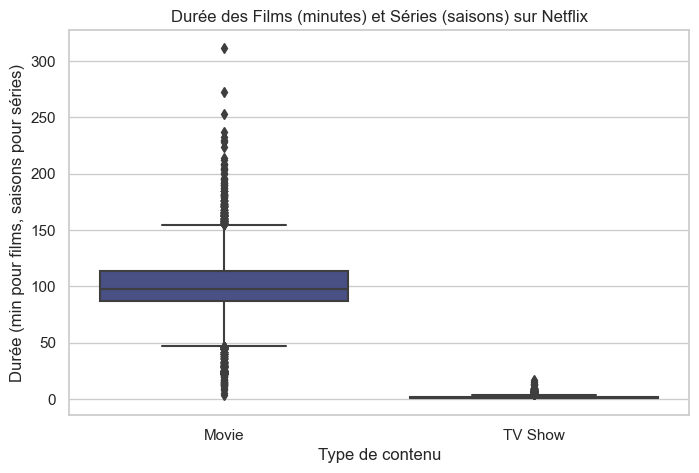

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="type", y="duration_value", palette="mako")

plt.title("Durée des Films (minutes) et Séries (saisons) sur Netflix")
plt.xlabel("Type de contenu")
plt.ylabel("Durée (min pour films, saisons pour séries)")
plt.show()
#1ere methode , difficile a lire puisque le différences entre nb minutes et nbsaisons est très grande

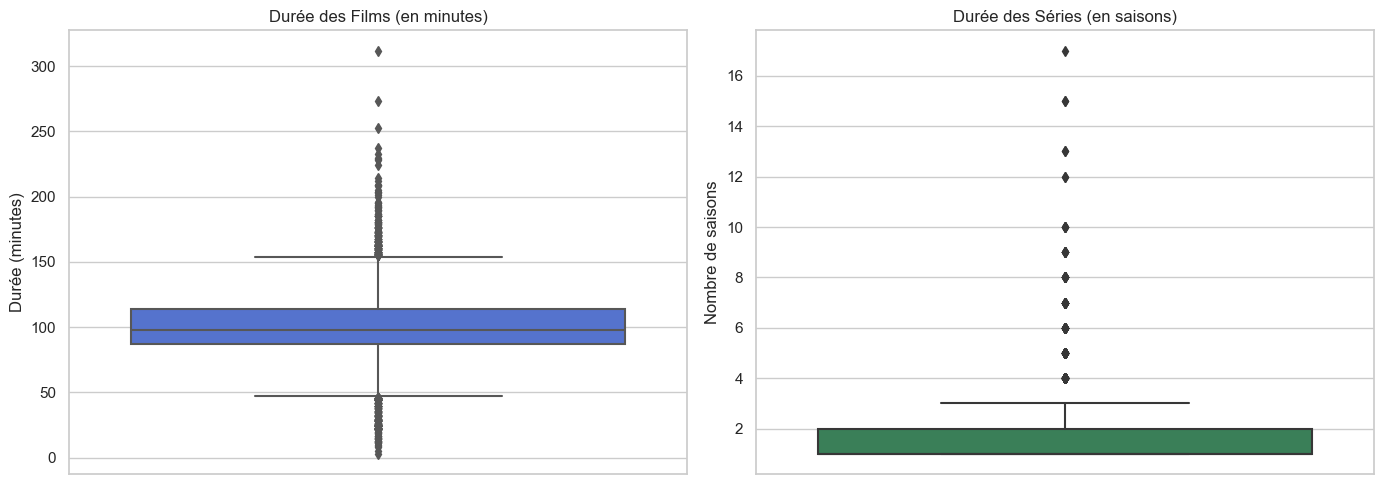

In [74]:
#2ème méthode
# 4) Boxplots Films vs Séries
fig_box, axes = plt.subplots(1, 2, figsize=(14,5)) 
# Boxplot pour les films
sns.boxplot(
    data=df[df["type"]=="Movie"],
    y="duration_value",
    ax=axes[0],
    color="royalblue"
)
axes[0].set_title("Durée des Films (en minutes)")
axes[0].set_ylabel("Durée (minutes)")

# Boxplot pour les séries
sns.boxplot(
    data=df[df["type"]=="TV Show"],
    y="duration_value",
    ax=axes[1],
    color="seagreen"
)
axes[1].set_title("Durée des Séries (en saisons)")
axes[1].set_ylabel("Nombre de saisons")

plt.tight_layout()
plt.show()


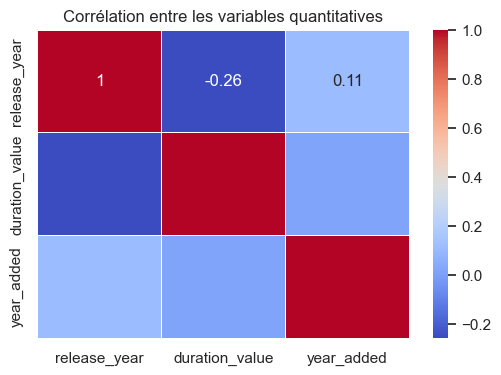

In [75]:
#4 heatmap pour faire la Corrélation entre variables quantitatives 
#release_year
#duration_value
#year_added
# Sélectionner uniquement les colonnes numériques
numeric_df = df[["release_year", "duration_value", "year_added"]]
# Calcul de la matrice de corrélation
corr_matrix = numeric_df.corr()
# Afficher la heatmap
fig_heatmap = plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Corrélation entre les variables quantitatives")
plt.show()

In [76]:
#release_year vs duration_value → presque 0

#release_year vs year_added → un peu plus corrélé

#duration_value vs year_added → presque 0

In [77]:
#Analyse Additionnelle 1 : Répartition des contenus par Rating (classification d’âge)
#Analyse Additionnelle 2 : Évolution des contenus ajoutés par Année (year_added)

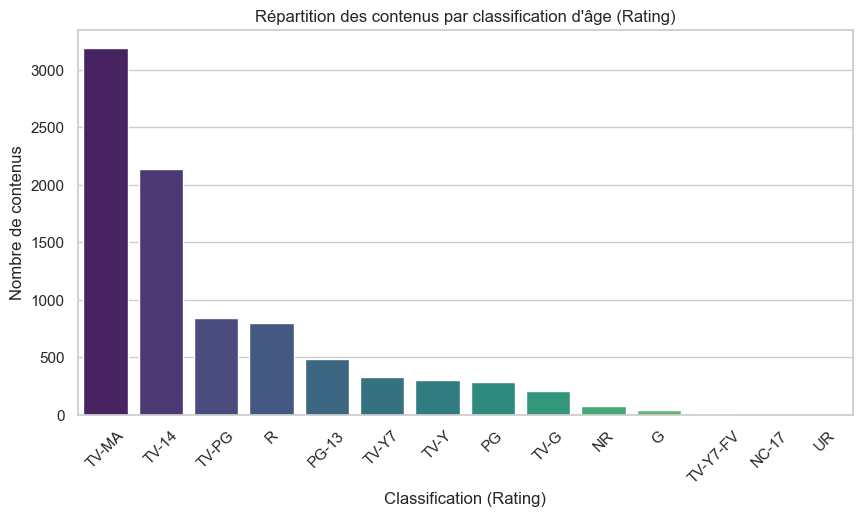

In [78]:
#Analyse Additionnelle 1 : Répartition des contenus par Rating (classification d’âge)

fig_rating = plt.figure(figsize=(10,5))
sns.countplot(data=df, x="rating", order=df["rating"].value_counts().index, palette="viridis")

plt.title("Répartition des contenus par classification d'âge (Rating)")
plt.xlabel("Classification (Rating)")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)
plt.show()

In [79]:
#L’analyse de la répartition des ratings montre une forte dominance des classifications TV-MA et TV-14, 
#ce qui indique que Netflix cible principalement un public adulte ou adolescent.
#Les classifications jeunes (TV-Y, TV-G) sont largement minoritaires, révélant que le contenu “famille”
#représente une part assez faible dans le catalogue.
#Cette distribution reflète la stratégie de Netflix d’investir davantage dans des séries et films matures, 
#plus populaires auprès de son audience principale
#TV-MA Réservé aux adultes (17+)
#TV-14 Public adolescent (14+)
#TV-PG (Parental Guidance) Déconseillé sans supervision parentale
#R (Restricted) Interdit aux moins de 17 ans non accompagnés
#PG-13 Déconseillé aux moins de 13 ans
#TV-Y7 Pour enfants 7+
#TV-Y Pour jeunes enfants (presque tout public)
#TV-G Tout public
#PG Supervision parentale
#NR (Not Rated) Non classé
#NC-17 Strictement adultes
#TV-Y7-FV Pour enfants mais avec scènes de "Fantasy Violence"
#UR (Unrated)Non évalué officiellement

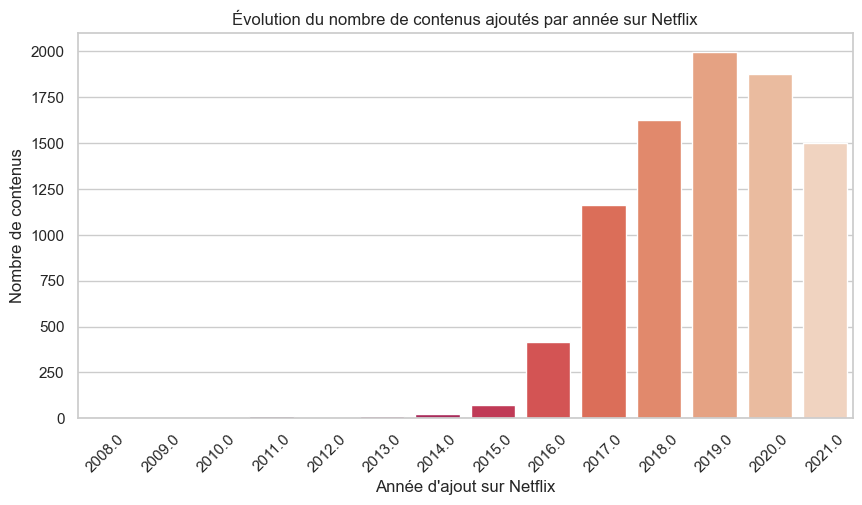

In [80]:
#Analyse Additionnelle 2 : Évolution des contenus ajoutés par Année (year_added)
fig_year_added = plt.figure(figsize=(10,5))

sns.countplot(
    data=df, 
    x="year_added", 
    order=sorted(df["year_added"].dropna().unique()),
    palette="rocket"
)

plt.title("Évolution du nombre de contenus ajoutés par année sur Netflix")
plt.xlabel("Année d'ajout sur Netflix")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)
plt.show()

In [81]:
# L’évolution du catalogue Netflix montre une croissance spectaculaire à partir de 2016,
#correspondant à l’expansion internationale de la plateforme et à l’investissement massif dans les productions originales.
#Le nombre de contenus ajoutés atteint un pic entre 2019 et 2021, période durant laquelle Netflix a accéléré
#l’acquisition et la production de contenus en réponse à l’augmentation mondiale de la demande pour les services de streaming, 
#notamment durant la pandémie.
#Cette tendance confirme la stratégie agressive de Netflix visant à élargir rapidement son catalogue pour attirer
#et fidéliser ses abonnés.

In [82]:
fig_films_series.savefig("netflix_1_films_series.png", bbox_inches="tight")
fig_top10.savefig("netflix_2_top10_pays.png", bbox_inches="tight")
fig_hist_release_year.savefig("netflix_3_hist_release_year.png", bbox_inches="tight")
fig_box.savefig("netflix_4_boxplots_duree.png", bbox_inches="tight")
fig_heatmap.savefig("netflix_5_heatmap_corr.png", bbox_inches="tight")
fig_rating.savefig("netflix_6_rating.png", bbox_inches="tight")
fig_year_added.savefig("netflix_7_year_added.png", bbox_inches="tight")

In [84]:
# 2) Créer un dashboard HTML simple pour Netflix

images = [
    ("Comparaison Films vs Séries", "netflix_1_films_series.png"),
    ("Top 10 des pays producteurs", "netflix_2_top10_pays.png"),
    ("Distribution des années de sortie", "netflix_3_hist_release_year.png"),
    ("Durée des films et des séries (boxplots)", "netflix_4_boxplots_duree.png"),
    ("Corrélation entre variables quantitatives", "netflix_5_heatmap_corr.png"),
    ("Répartition des contenus par Rating", "netflix_6_rating.png"),
    ("Évolution des contenus ajoutés par année", "netflix_7_year_added.png"),
]

html_parts = []

for title, filename in images:
    html_parts.append(f"<h2>{title}</h2>")
    html_parts.append(f"<img src='{filename}' style='max-width:100%; height:auto;'>")
    html_parts.append("<hr>")   # séparateur
content = "\n".join(html_parts)

full_html = f"""
<html>
<head>
    <meta charset="utf-8">
    <title>Dashboard Netflix – Analyse Exploratoire</title>
</head>
<body style="font-family:Arial, sans-serif; margin:20px;">
    <h1>Dashboard Netflix – Analyse Exploratoire</h1>
    <p>Ce rapport regroupe les principales visualisations réalisées sur le dataset Netflix :
    comparaison films/séries, pays producteurs, distribution temporelle, durées, corrélations
    et analyses additionnelles.</p>

    {content}
</body>
</html>
"""

with open("dashboard_netflix.html", "w", encoding="utf-8") as f:
    f.write(full_html)